In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
kB = 1.380649*10**(-23) #J/K

In [3]:
ergs = 10**(-7) #J
MeV = 1.6 * 10**(-13) #J
km = 1000*100 #cm
Mpc = 3.0857*10**22 #m

In [4]:
Axion_emissivity_n0 = pd.read_csv('compare_4_axion_emissivities_1n0.txt', sep="\t", header=None) 
#ergs/(cm^3*s) 
#at nuclear saturation density (less-prediction)

Axion_emissivity_7n0 = pd.read_csv('compare_4_axion_emissivities_7n0.txt', sep="\t", header=None) 
#ergs/(cm^3*s) 
#at 7 times the nuclear saturation density (less-prediction)

In [5]:
Axion_emissivity_n0
#The columns are: Temperature, red, blue, green, D, ND.  (Corresponding to the colors/labels used in the figure)
# green is PS (non-relativistic) (minimum prediction)
# red is FS (maximum prediction)

,0,1,2,3,4,5,6
0,10,8.710000e+32,8.130000e+32,5.610000e+32,1.100000e+33,3.660000e+32,3.860000e+32
1,15,9.920000e+33,7.590000e+33,4.510000e+33,8.520000e+33,3.660000e+33,2.960000e+33
2,20,5.580000e+34,3.250000e+34,1.730000e+34,4.060000e+34,2.080000e+34,1.100000e+34
3,25,2.130000e+35,9.220000e+34,4.660000e+34,1.090000e+35,6.080000e+34,2.820000e+34
4,30,6.350000e+35,2.040000e+35,9.950000e+34,2.820000e+35,1.690000e+35,5.930000e+34
5,35,1.600000e+36,3.840000e+35,1.820000e+35,5.380000e+35,3.420000e+35,1.040000e+35
6,40,3.570000e+36,6.440000e+35,3.030000e+35,1.010000e+36,6.600000e+35,1.640000e+35
7,45,7.230000e+36,9.910000e+35,4.730000e+35,1.700000e+36,1.160000e+36,2.470000e+35
8,50,1.360000e+37,1.430000e+36,6.820000e+35,2.780000e+36,1.930000e+36,3.380000e+35
9,55,2.410000e+37,1.960000e+36,9.350000e+35,3.780000e+36,2.680000e+36,4.490000e+35


In [6]:
Axion_emissivity_7n0

,0,1,2,3,4,5
0,10,2.180000e+33,2.140000e+33,2.240000e+33,2.680000e+33,7.060000e+32
1,15,2.490000e+34,2.480000e+34,1.570000e+34,2.520000e+34,8.620000e+33
2,20,1.400000e+35,1.390000e+35,7.580000e+34,1.600000e+35,6.480000e+34
3,25,5.330000e+35,5.310000e+35,3.080000e+35,6.200000e+35,2.720000e+35
4,30,1.590000e+36,1.580000e+36,8.700000e+35,1.760000e+36,8.320000e+35
5,35,4.010000e+36,3.990000e+36,2.200000e+36,4.480000e+36,2.260000e+36
6,40,8.940000e+36,8.840000e+36,4.450000e+36,9.720000e+36,5.020000e+36
7,45,1.810000e+37,1.780000e+37,8.980000e+36,1.830000e+37,9.880000e+36
8,50,3.410000e+37,3.290000e+37,1.580000e+37,3.240000e+37,1.780000e+37
9,55,6.040000e+37,5.720000e+37,2.600000e+37,5.740000e+37,3.220000e+37


In [7]:
#needs r in km
#returns Temperature in MeV

def low_T(r):
    if r<6:
        return 32.5 * (r/6)**0.85
    else:
        return 32.5 * (r/6)**(-1.33)
    
def high_T(r):
    if r<6:
        return 41.8 * (r/6)**1.03
    else:
        return 41.8 * (r/6)**(-1.06)

In [8]:
low_T_r = []
high_T_r = []
r_shell = np.arange(2,18.5,0.5)
for r in r_shell:
    low_T_r.append(low_T(r))
    high_T_r.append(high_T(r))

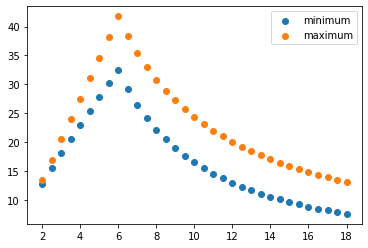

In [9]:
plt.scatter(r_shell, low_T_r, label = "minimum")
plt.scatter(r_shell, high_T_r, label = "maximum")

plt.legend()
plt.show()

In [10]:
high_T_approx = np.around(np.divide(high_T_r, 5))*5
low_T_approx = np.around(np.divide(low_T_r, 5))*5

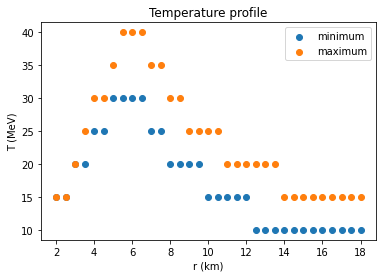

In [11]:
plt.scatter(r_shell, low_T_approx, label = "minimum")
plt.scatter(r_shell, high_T_approx, label = "maximum")

plt.xlabel("r (km)")
plt.ylabel("T (MeV)")
plt.title("Temperature profile")
plt.legend()
plt.show()

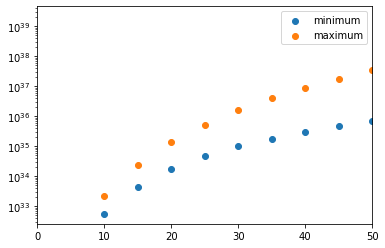

In [12]:
plt.scatter(Axion_emissivity_n0[0].values, Axion_emissivity_n0[3].values, label = "minimum")
plt.scatter(Axion_emissivity_7n0[0].values, Axion_emissivity_7n0[1].values, label = "maximum")

plt.yscale('log')
plt.xlim(0,50)
plt.legend()
plt.show()

In [13]:
T = Axion_emissivity_n0[0].values
axion_energy = 3*T #MeV

In [14]:
axion_emissivity_minimum = []
axion_emissivity_maximum = []

for i in range(0, np.shape(r_shell)[0]):
    axion_energy_high = 3*high_T_approx[i]
    axion_energy_low = 3*low_T_approx[i]
    axion_emissivity_minimum.append(Axion_emissivity_n0[Axion_emissivity_n0[0] == low_T_approx[i]][3].values[0]*ergs/(axion_energy_low*MeV))
    axion_emissivity_maximum.append(Axion_emissivity_7n0[Axion_emissivity_7n0[0] == high_T_approx[i]][1].values[0]*ergs/(axion_energy_high*MeV))

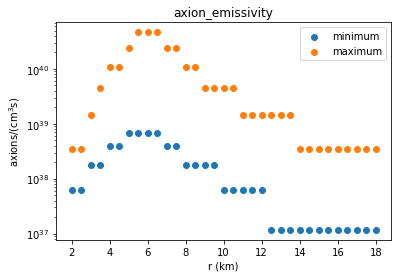

In [15]:

plt.scatter(r_shell, axion_emissivity_minimum, label = "minimum")
plt.scatter(r_shell, axion_emissivity_maximum, label = "maximum")

plt.xlabel("r (km)")
plt.ylabel(r"axions/(cm$^3$s)")
plt.title("axion_emissivity")
plt.legend()
plt.yscale('log')
plt.show()

In [16]:
axion_emitted_minimum = []
axion_emitted_maximum = []

for i in range(0, np.shape(r_shell)[0]):
    Volume = 4*3.14*(r_shell[i]*km)**2*0.5
    axion_emitted_minimum.append(axion_emissivity_minimum[i]*Volume)
    axion_emitted_maximum.append(axion_emissivity_maximum[i]*Volume)

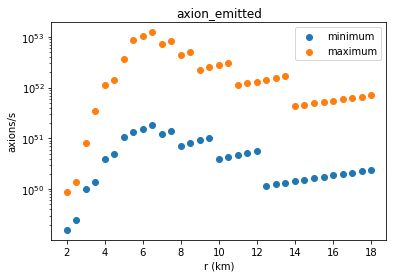

In [17]:
plt.scatter(r_shell, axion_emitted_minimum, label = "minimum")
plt.scatter(r_shell, axion_emitted_maximum, label = "maximum")

plt.xlabel("r (km)")
plt.ylabel(r"axions/s")
plt.title("axion_emitted")
plt.legend()
plt.yscale('log')
plt.show()

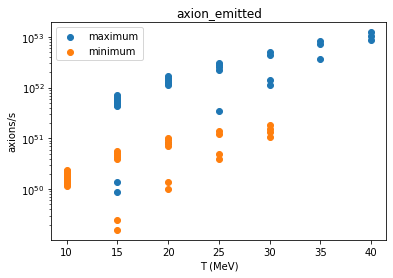

In [18]:
plt.scatter(high_T_approx, axion_emitted_maximum, label = "maximum")
plt.scatter(low_T_approx, axion_emitted_minimum, label = "minimum")

plt.xlabel("T (MeV)")
plt.ylabel(r"axions/s")
plt.title("axion_emitted")
plt.legend()
plt.yscale('log')
plt.show()

In [19]:
axion_spectra_maximum = []
high_T_unique = np.unique(high_T_approx)
for T in high_T_unique:
    axion_T_maximum = 0
    for i in range(0, np.shape(r_shell)[0]):
        if high_T_approx[i] == T:
            axion_T_maximum = axion_T_maximum + axion_emitted_maximum[i]
    axion_spectra_maximum.append(axion_T_maximum)

In [20]:
axion_spectra_minimum = []
low_T_unique = np.unique(low_T_approx)
for T in low_T_unique:
    axion_T_minimum = 0
    for i in range(0, np.shape(r_shell)[0]):
        if low_T_approx[i] == T:
            axion_T_minimum = axion_T_minimum + axion_emitted_minimum[i]
    axion_spectra_minimum.append(axion_T_minimum)

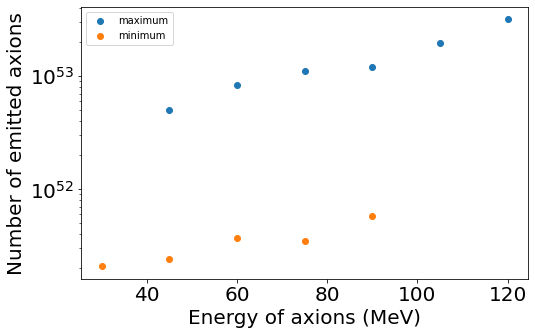

In [21]:
f = plt.figure(figsize=(8,5))

plt.scatter(3*high_T_unique, axion_spectra_maximum, label = "maximum")
plt.scatter(3*low_T_unique, axion_spectra_minimum, label = "minimum")

plt.xlabel("Energy of axions (MeV)", fontsize=20)
plt.ylabel(r"Number of emitted axions", fontsize=20)
#plt.title("axion_emitted", fontsize=20)
plt.legend()
plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [23]:
np.sum(axion_spectra_minimum)

1.7468908969444443e+52

In [24]:
np.sum(axion_spectra_maximum)

8.762265975595236e+53

In [53]:
distance_merger = 40 * Mpc #m #for GW170817

In [54]:
axion_earth_maximum = []
axion_earth_minimum = []
for i in range(0, np.shape(low_T_unique)[0]):
    axion_earth_minimum.append(axion_spectra_minimum[i]/(4*3.14*distance_merger**2))

for i in range(0, np.shape(high_T_unique)[0]):    
    axion_earth_maximum.append(axion_spectra_maximum[i]/(4*3.14*distance_merger**2))

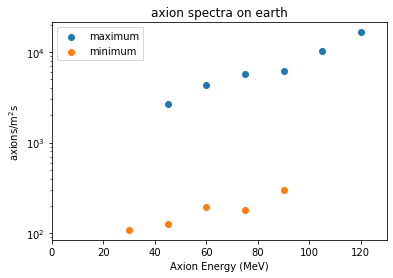

In [55]:
plt.scatter(3*high_T_unique, axion_earth_maximum, label = "maximum")
plt.scatter(3*low_T_unique, axion_earth_minimum, label = "minimum")

plt.xlabel("Axion Energy (MeV)")
plt.ylabel(r"axions/m$^2$s")
plt.title("axion spectra on earth")
plt.legend()
plt.yscale('log')
plt.xlim(0,130)
plt.show()